# Resumen: Técnica de Balanceo SMOTE — Análisis Comparativo Adicional
## Proyecto Final ML — Predicción del Rendimiento Estudiantil

---
Vamos a hacer un análisis comparativo usando SMOTE. Esto tiene sentido probarlo debido a que class_weight actúa modificando los pesos de la función de pérdida pero NO MODIFICA EL ESPACIO DE DATOS. 
SMOTE en cambio enriquece directamente el conjunto de entrenamiento y que el modelo vea más ejemplos de las clases raras en el ajuste. Es una estrategia diferente.

La pregunta central es: **¿cambia el rendimiento final si equilibramos las clases *antes* de entrenar (SMOTE) en lugar de ponderar los errores *durante* el entrenamiento (`class_weight="balanced"`)?**

**Modelos evaluados:** Regresión Logística · Random Forest  
**Métrica principal:** Macro F1-score  
**Clases objetivo:** `abandono` · `graduado` · `matriculado`  
**Script de referencia:** `smote.py`

---
## 1. Distribución de clases antes y después de SMOTE

SMOTE es una técnica de oversampling que genera ejemplos sintéticos interpolando entre muestras existentes. El mecanismo es: para cada muestra de la clase minoritaria, selecciona aleatoriamente uno de sus k vecinos más cercanos dentro de esa misma clase y geenra un punto nuevo en algún lugar del segmento que une a los dos puntos en el espacio de features

Hemos usado varios parámetros interesantes:

- `sampling_strategy="auto"`: Esto hace que SMOTE lleve todas las clases minoritarias hasta igualar a la mayoritaria. Esta decisión es bastante radical y tiene consecuencias importantes sobre lo que analizaremos en el notebook.

- `k_neighbors=5`: Cada muestra sintética se crea interpolando con uno de sus 5 vecinos más cercanos dentro de su clase. Con k grande producimos muestras más distribuidas en el espacio de features.

- `random_state=42`: reproducibilidad.

> SMOTE SE APLICA SOBRE EL CONJUNTO DE TRAIN. HACERLO SOBRE TEST GENERARÍA DATA LEAKAGE Y PRODUCIRÍA RESULTADOS NEFASTOS EN TEST



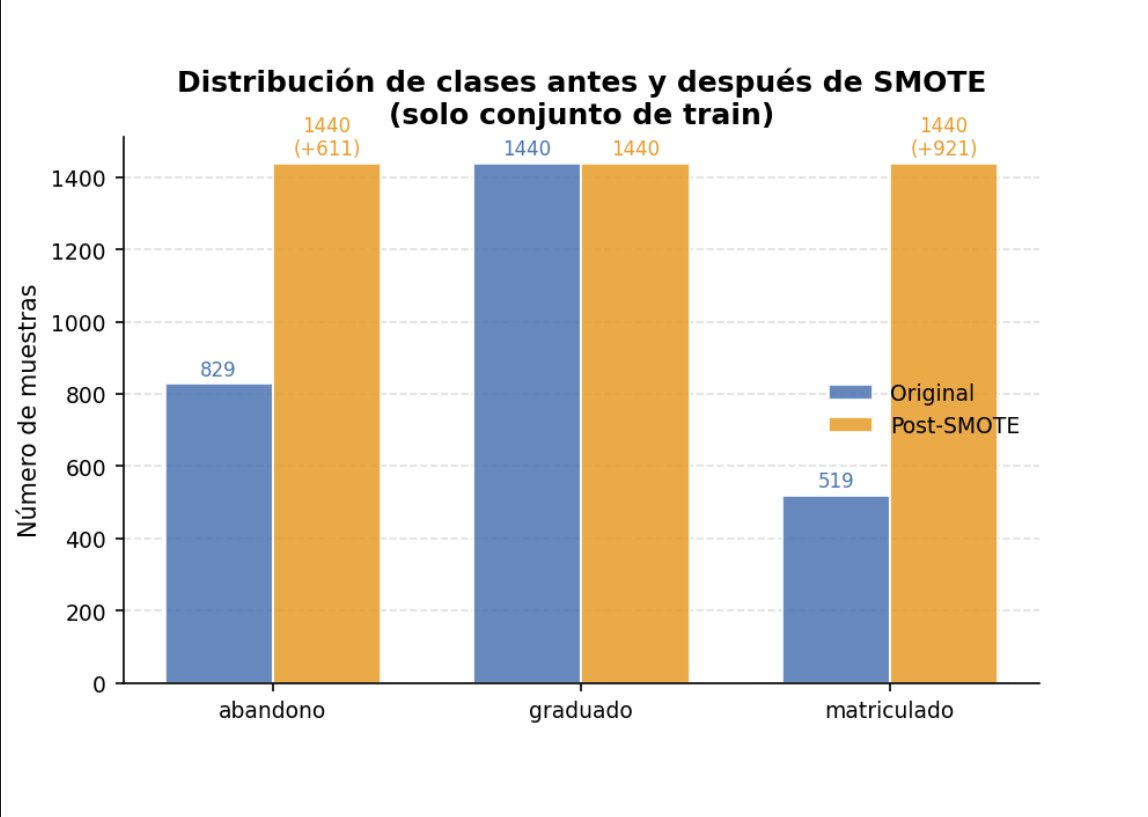

### Análisis de la distribución
> Vemos que hemos generado muestras sintéticas de las clases desbalanceadas para igualar la representabilidad de cada clase en el dataset.
> La clase que más se ha beneficiado con estas muestras artificiales es "matriculado" ya que sabíamos que era la más infrarrepresentada en el conjunto original

---
## 2. Matrices de confusión y comparativa SMOTE vs `class_weight`

Los modelos se entrenaron con `GridSearchCV` (k=5 folds) sobre los datos aumentados con SMOTE, sin `class_weight` (ya que el balanceo lo realiza SMOTE directamente).

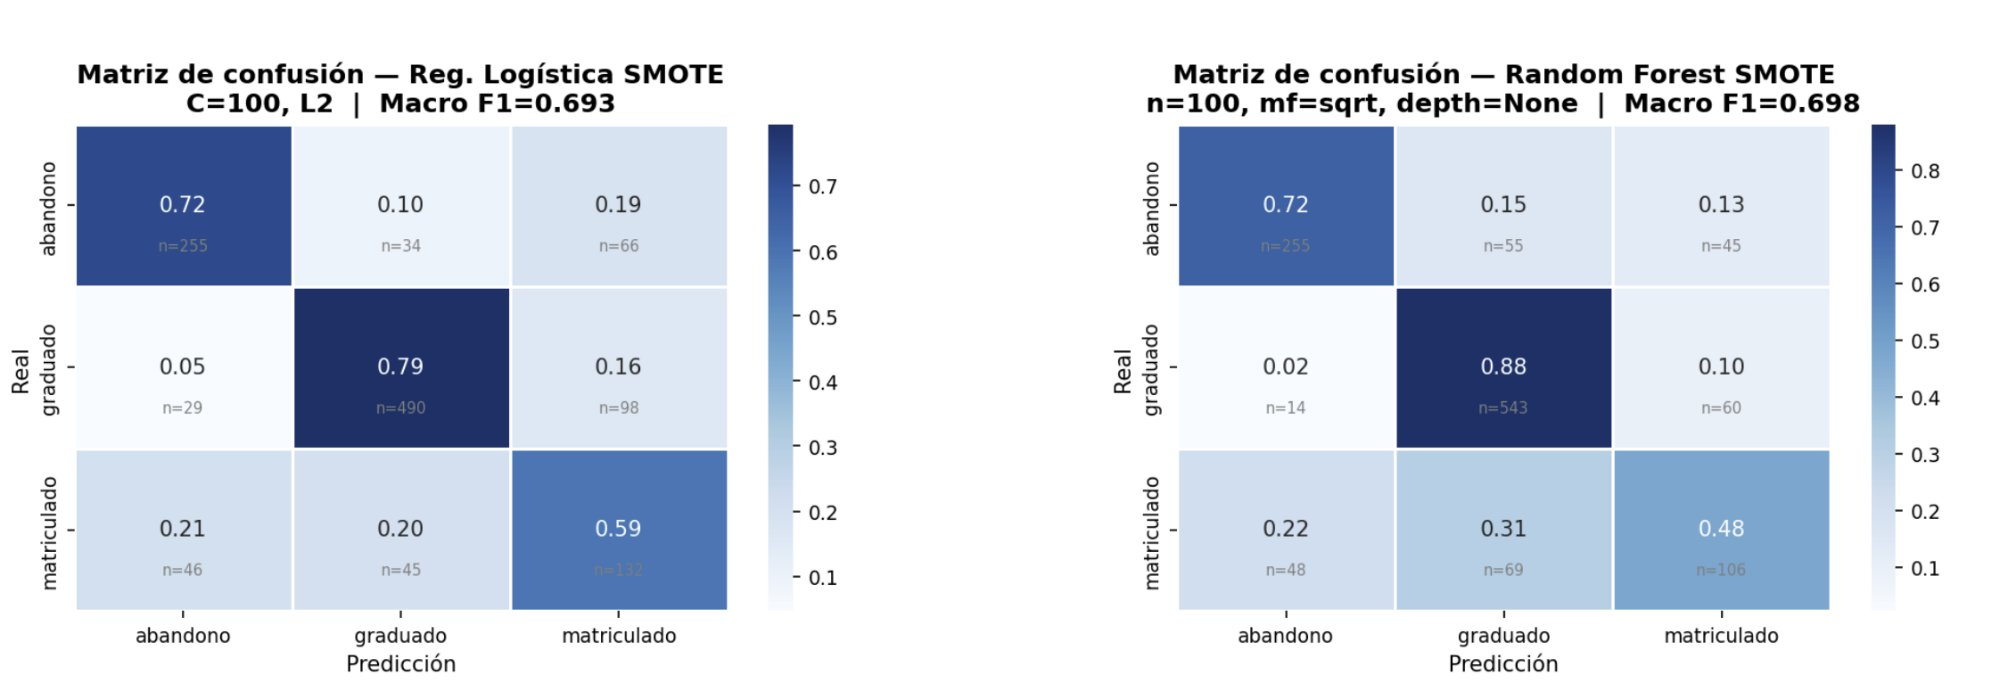

### 📝 Análisis de las matrices de confusión

| Modelo | Estrategia | Recall abandono | Recall graduado | Recall matriculado |
|---|---|---|---|---|
| Reg. Logística | `class_weight` | 0.72 | 0.81 | 0.65 |
| Reg. Logística | SMOTE | 0.72 | 0.79 | 0.59 |
| Random Forest | `class_weight` | 0.72 | 0.92 | 0.42 |
| Random Forest | SMOTE | 0.72 | 0.88 | 0.48 |

Ambos modelos muestran un comportamiento muy similar entre estrategias. El patrón de errores es consistente: la clase `matriculado` es la más difícil de predecir en todos los casos, lo que sugiere que la dificultad es inherente a la clase y no a la estrategia de balanceo.

> Vemos que las métricas salen similares y que la clase "matriculado" es la más difícil de predecir en todos los casos. Eso confirma lo que pensábamos en los modelos anteriores: que esa clase obtenía malas métricas debido a la naturaleza semántica de esa clase y no por la estrategia de balanceo que habíamos usado.

>Algo sorprendente es que el recall sobre abandono no cambia nada con los modelos ni con las técnicas distintas de gestionar desbalanceos. Esto nos chiva algo que ya veníamos viendo a lo largo del proyecto pero que confirmamos con aún más fuerza ahora que vemos esto. La clase abandono está muy bien diferenciada: un perfil con pocos aprobados, muchas asignaturas sin evaluar, notas bajas... Todo eso forma un perfil compacto y muy separable en el espacio de features. Abandono ya era bien clasificable sin necesidad de corrección. Por eso ni class_weight ni SMOTE mueven esa frontera que era ya robusta

> El tema es que con SMOTE estamos llevando a abandono y matriculado también a 1440 muestras con muchas de ellas sintéticas. El problema es que la clase matriculado, como vimos en KNN, tiene una dispersión geométrica importante mezclándose mucho entre otra clases. Por tanto, los datos sintéticos creados interpolando acaban en zonas donde antes dominaba graduado. Entonces el modelo aprende una frontera menos robusta. Estamos entonces haciendo que el modelo aprenda fronteras más conservadores con esa clase porque su espacio de decisión que antes era más claro ha sido degradado por puntos sintéticos. Entonces perdemos algo de recall en graduado y el propio matriculado. En Random Forest occure algo parecido, era el que mejor clasificaba graduado ya que capturaba patrones no lineales pero al introducir ese ruido sintético en regiones que antes eran más claras obtenemos menos rendimiento.


> Obtenemos una conclusión muy reveladora: la dificultad de matriculado no es un problema de desbalanceo numérico, es un problema de SEPARABILIDAD SEMÁNTICA. De hecho el recall de abandono también nos permite ver que si la clase tiene un perfil claro no necesita ayuda de desbalanceo. Con SMOTE solo hemos amplificado un problema de naturaleza semántica de una de las clases (eso le afecta geométricamente) provocando que el modelo genere entre esas clases una frontera más conservadora, captando menos una realidad que estaba ligeramente mejor representada cuando no generábamos muestras sintéticas y simplemente usábamos class weight = "balanced"

---
## 3. Comparativa Macro F1: SMOTE vs `class_weight`

La tabla siguiente resume de forma directa el impacto de cada estrategia de balanceo sobre la métrica principal del proyecto.

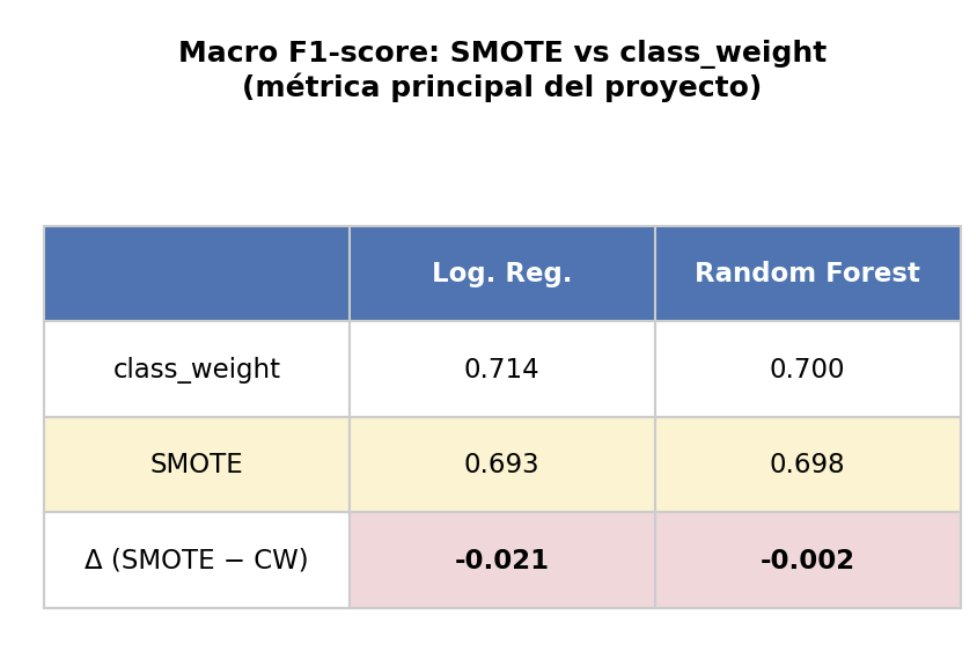

### 📝 Interpretación de la comparativa

| | Log. Reg. | Random Forest |
|---|---|---|
| `class_weight` | 0.714 | 0.700 |
| SMOTE | 0.693 | 0.698 |
| Δ (SMOTE − CW) | **−0.021** | **−0.002** |

**Conclusiones principales:**

> Vemos que al igual que el Macro F1 obtenido en validación cruzada, el Macro F1
- `class_weight="balanced"` supera a SMOTE en ambos modelos, aunque la diferencia es muy pequeña (especialmente en Random Forest: solo −0.002).
- En Regresión Logística la diferencia es algo mayor (−0.021), lo que sugiere que para modelos lineales el ajuste de pesos interno es más eficiente que generar muestras sintéticas en el espacio de features.
- Random Forest es más robusto al método de balanceo: su rendimiento apenas varía (0.700 vs 0.698), posiblemente porque los árboles de decisión ya manejan bien la heterogeneidad local de los datos.
- SMOTE introduce muestras sintéticas que podrían añadir ruido en zonas de frontera difusas, lo que explica el ligero descenso en la clase `matriculado` en Regresión Logística.
- A pesar de no superar a `class_weight`, SMOTE es una técnica válida y su implementación permite explorar si el problema era de **escasez real de ejemplos** o simplemente de **desajuste en la función de pérdida**. La respuesta aquí apunta a lo segundo.

> En relación con lo explicado anteriormente, obtenemos peor Macro F1 en test usando SMOTE. Vemos que las diferencias de rendimiento no son enormes pero en Regresión logística es algo mayor. Eso nos sugiere que para modelos lineales el ajuste de pesos interno es más eficiente que generar muestras sintéticas en el espacio de features. Sobre todo en caso dónde la distribución de los puntos originales es problemática y por tanto cuya interpolación genera ruido más que ayuda para el modelo. 
> En Random Forest, que es el modelo en el que más esperábamos una mejoría debido al peor funcionamiento de class weight = "balanced" deducido en la parte de RF del proyecto, vemos que hemos perdido también un poco de rendimiento. RF es más robusto al método de balanceo. Lo que ha pasado es que ese efecto de dilución que perjudicaba a class weight lo hemos evitado pero al introducir muestras sintéticas no tan buenas pues hemos acabado generando ruido.
> Lo que tenemos que entender es que a pesar de no haber superado a class weight, SMOTE es una técnica válida y nos permite también verificar si el problema era de escasez de ejemplos o simplemente de un problema inherente a la naturaleza semántica de una de las clases del problema

---
## 4. Detalles de implementación (`smote.py`)

El script `smote.py` sigue el mismo flujo que los modelos principales del proyecto:

1. **Carga** de los mismos ficheros `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` usados en `logistic_regression.py` y `random_forest.py`.
2. **Aplicación de SMOTE** solo sobre train (`X_train_sm`, `y_train_sm`).
3. **GridSearchCV (k=5)** para Regresión Logística: misma rejilla que el modelo original (C ∈ {0.001, 0.01, 0.1, 1, 10, 100} × {L1, L2} = 60 entrenamientos).
4. **GridSearchCV (k=5)** para Random Forest: misma rejilla que el modelo original (n_estimators × max_features × max_depth = 40 entrenamientos).
5. **Evaluación** sobre el test original (sin SMOTE).
6. **Visualización**: distribución de clases, matrices de confusión, tabla comparativa y métricas por clase.

**Mejor configuración encontrada:**
- Regresión Logística SMOTE: `C=100`, `penalty=L2` → Macro F1 = 0.693
- Random Forest SMOTE: `n=100`, `max_features=sqrt`, `max_depth=None` → Macro F1 = 0.698

<div style="border: 2px solid #2e86c1; border-radius: 8px; padding: 20px 24px; margin: 28px 0; background-color: #eaf4fb; color: #000000;">
<h3 style="color: #1a5276; margin-top: 0; padding-bottom: 8px; border-bottom: 1px solid #aed6f1; margin-bottom: 14px;">Conclusiones finales — Análisis SMOTE</h3>


Hemos obtenido una conclusión reveladora: la dificultad de clasificación observada no es fundamentalmente debido al desbalance y la técnica usada para tratarlo sino por una propiedad intrínseca de la geometría del espacio de features.

SMOTE, al generar puntos sintéticos mediante interpolación lineal entre vecinos de la misma clase, presupone que el espacio intermedio entre dos puntos de una clase también es representativo de ella. Sin embargo, ese supuesto se rompe sobre todo con las clases Matriculado y Graduado ya que presentan regiones de solapamiento importante. Por tanto los puntos sintéticos generados caen en zonas de alta ambigüedad introduciendo un ruido que lleva al clasificador a aprender una frontera de decisión mucho más conservadora y menos precisa. Por tanto las desventajas que aportaba class weight se han intercambiado por un ruido también problemático y en ese trade-off el modelo pierde rendimiento ligeramente en ambos modelos.

Otra cosa interesante vista es que las métricas de la clase Abandono no se ven afectadas por las distintas técnicas de desbalance. Esto nos indica que esta clase ocupa una región del espacio de features suficientemente compacta y bien separada como para que ninguna estrategia de desbalance le afecte. Tiene sentido debido a que el perfil de estudiante que abandona es más distinguible por juntar factores como rendimiento académico bajo, deudas, ausencia de becas…

Por tanto el camino para mejorar la clasificación entre Matriculado y Graduado no pasa por técnicas de rebalanceo sino por influir features más ricas en el dataset que permitan separar aún más fácilmente los distintos perfiles


</div>